In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [145]:
class SymbolGenerator:
    def __init__(self, data_path):
        self.data_path = data_path
        self.available_symbols = list(('(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*'))
        print("Доступные символы:", self.available_symbols)
        
    def get_random_symbol_image(self, char):
        folder_name = char
        if (char == 'x'):
            folder_name = 'X'
        if (char == '*'):
            folder_name = 'times'
        symbol_dir = os.path.join(self.data_path, folder_name)
        
        images = [f for f in os.listdir(symbol_dir)]
        images.sort() 
        start_index = int(len(images) * 0.8)
        last_30_percent = images[start_index:]

        random_image = random.choice(last_30_percent)
        img_path = os.path.join(symbol_dir, random_image)
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)    
        return img
    
    def generate_sequence(self, length=4):
        sequence = ''.join(random.choices(self.available_symbols, k=length))
        print(f"Генерируем: {sequence}")
        images = []
        
        for char in sequence:
            img = self.get_random_symbol_image(char)
            if img is not None:
                images.append(img)
        
        return sequence, images

generator = SymbolGenerator('C:\\test_data\\')

Доступные символы: ['(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*']


In [146]:
def create_sequence_image(images, spacing=20):
    total_width = sum(img.shape[1] for img in images) + spacing * (len(images) - 1)
    max_height = max(img.shape[0] for img in images)
    
    sequence_img = np.ones((max_height, total_width), dtype=np.uint8) * 255
    
    x_offset = 0
    for img in images:
        h, w = img.shape
        y_offset = (max_height - h)
        sequence_img[y_offset:y_offset+h, x_offset:x_offset+w] = img
        x_offset += w + spacing
    
    return sequence_img

Генерируем: 0yx69t5479


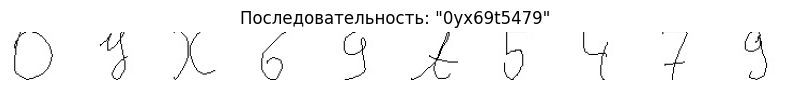

In [170]:
sequence, images = generator.generate_sequence(length=10)
sequence_image = create_sequence_image(images, spacing=30)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(sequence_image, cmap='gray')
ax.set_title(f'Последовательность: "{sequence}"')
ax.axis('off')

plt.tight_layout()
plt.show()

Обрабатываем последовательность: '0yx69t5479'


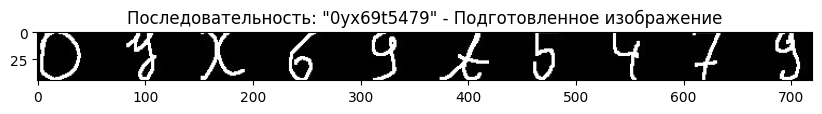

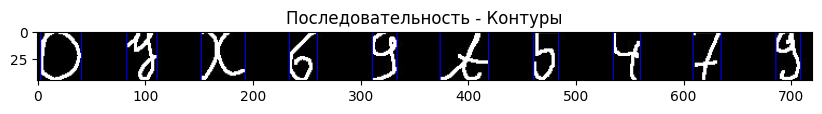

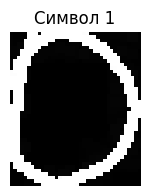

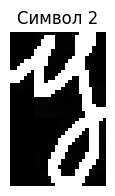

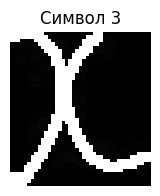

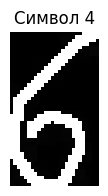

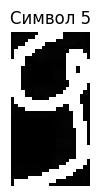

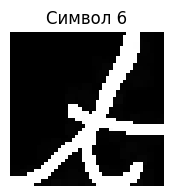

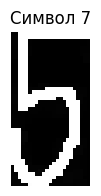

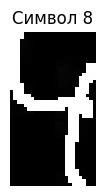

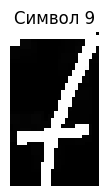

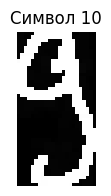

In [171]:
all_data_img = []

print(f"Обрабатываем последовательность: '{sequence}'")

img_gray = sequence_image
kernel = np.ones((3,3),np.uint8)
img_gray = cv2.erode(img_gray,kernel,iterations = 1)
img_gray = cv2.bitwise_not(img_gray)
base_size=img_gray.shape[0],img_gray.shape[1]
base=np.zeros(base_size,dtype=np.uint8)
base[0:img_gray.shape[0],0:img_gray.shape[1]]=img_gray
base = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)

img_rgb = base

plt.figure(figsize=(10, 3))
plt.imshow(img_rgb)
plt.title(f'Последовательность: "{sequence}" - Подготовленное изображение')
plt.show()

ret,thresh = cv2.threshold(img_rgb,127,255,0)
thresh = np.uint8(thresh)

contours, h = cv2.findContours(thresh[:,:,0], cv2.RETR_EXTERNAL, 2)
crops = []

contours_sorted = sorted(contours, key=lambda cnt: cv2.boundingRect(cnt)[0])

for i in range(len(contours_sorted)):
    cnt = contours_sorted[i] 
    area = cv2.contourArea(cnt)
    x,y,w,h = cv2.boundingRect(cnt)
    while (w>45):
        w-=1
    
    if w*h > 50:
        cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(0,0,255),1)
        crops.append([x,y,w,h]) 

plt.figure(figsize=(10, 3))
plt.imshow(img_rgb)
plt.title(f'Последовательность - Контуры')
plt.show()

sequence_symbols = []
for i in range(len(crops)):
    x,y,w,h = crops[i]
    
    img_crop = img_gray[y:y+h, x:x+w]
    base = img_crop.copy()

    plt.figure(figsize=(3, 2))
    plt.imshow(base, cmap="gray")
    plt.title(f'Символ {i+1}')
    plt.axis('off')
    sequence_symbols.append((x, base))
    plt.show()

all_data_img.append({
    'sequence_text': sequence,
    'symbols': sequence_symbols
})

Центрирование символов:
  Символ 0 ('0'): (45, 38) -> (45, 45)
  Символ 1 ('y'): (45, 28) -> (45, 45)
  Символ 2 ('x'): (45, 41) -> (45, 45)
  Символ 3 ('6'): (45, 26) -> (45, 45)
  Символ 4 ('9'): (45, 23) -> (45, 45)
  Символ 5 ('t'): (45, 45) -> (45, 45)
  Символ 6 ('5'): (45, 23) -> (45, 45)
  Символ 7 ('4'): (45, 25) -> (45, 45)
  Символ 8 ('7'): (45, 26) -> (45, 45)
  Символ 9 ('9'): (45, 23) -> (45, 45)

Всего символов: 10
Последовательность: '0yx69t5479'


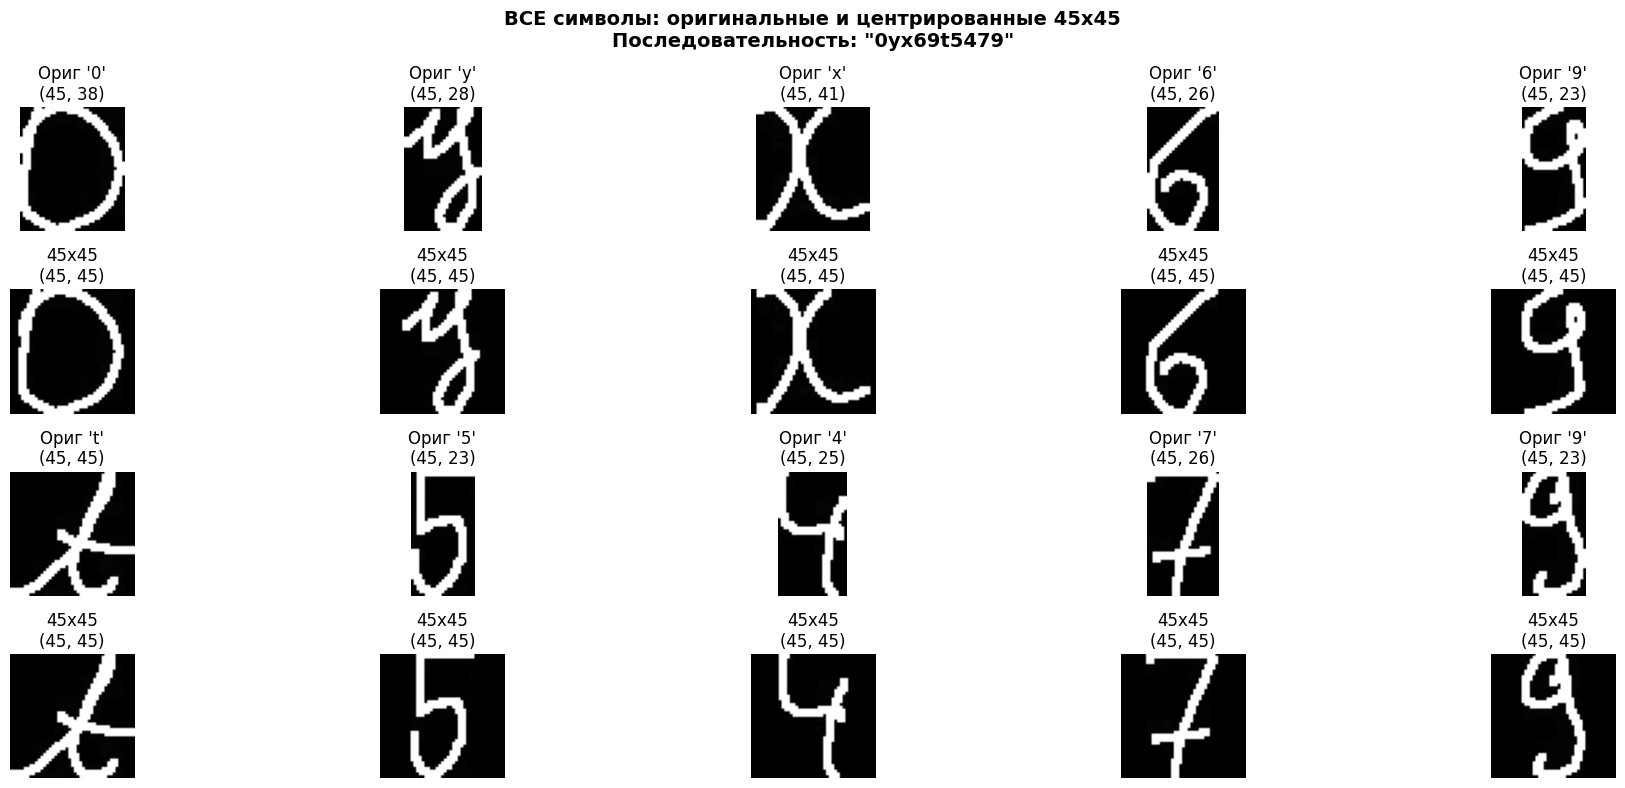


ИНФОРМАЦИЯ О СИМВОЛАХ:
  Всего символов: 10
  Последовательность: '0yx69t5479'
  Размер оригинальных символов: разный
  Размер центрированных: все 45x45

Проверка размеров:
  Все символы успешно центрированы в 45x45!


In [173]:
def center_in_45(image, target_size=45):
    h, w = image.shape
    
    squared = np.zeros((target_size, target_size), dtype=np.uint8)
    
    y_offset = (target_size - h) // 2
    x_offset = (target_size - w) // 2
    
    squared[y_offset:y_offset+h, x_offset:x_offset+w] = image
    return squared

all_data_img_45 = []

seq_data = all_data_img[0]  
sequence_text = seq_data['sequence_text']
symbols_data = seq_data['symbols']

symbols_sorted = sorted(symbols_data, key=lambda item: item[0])

resized_symbols = []
print("Центрирование символов:")
for i, (x, symbol_img) in enumerate(symbols_sorted):
    original_size = symbol_img.shape
    resized_img = center_in_45(symbol_img)
    resized_symbols.append((x, resized_img))
    
    char = sequence_text[i] if i < len(sequence_text) else '?'
    print(f"  Символ {i} ('{char}'): {original_size} -> {resized_img.shape}")

all_data_img_45.append({
    'sequence_text': sequence_text,
    'symbols': resized_symbols 
})

num_symbols = len(resized_symbols)
print(f"\nВсего символов: {num_symbols}")
print(f"Последовательность: '{sequence_text}'")

cols = min(5, num_symbols) 
rows = (num_symbols + cols - 1) // cols  

fig, axes = plt.subplots(2 * rows, cols, figsize=(4 * cols, 4 * rows))

if axes.ndim == 1:
    axes = axes.reshape(-1, 1)

for i in range(num_symbols):
    row_orig = (i // cols) * 2
    row_resized = row_orig + 1
    col = i % cols
    
    orig_img = all_data_img[0]['symbols'][i][1]
    axes[row_orig, col].imshow(orig_img, cmap='gray')
    if i < len(sequence_text):
        axes[row_orig, col].set_title(f"Ориг '{sequence_text[i]}'\n{orig_img.shape}")
    else:
        axes[row_orig, col].set_title(f"Ориг {i}\n{orig_img.shape}")
    axes[row_orig, col].axis('off')
    
    resized_img = resized_symbols[i][1]
    axes[row_resized, col].imshow(resized_img, cmap='gray')
    axes[row_resized, col].set_title(f"45x45\n{resized_img.shape}")
    axes[row_resized, col].axis('off')

for i in range(num_symbols, rows * cols):
    row_orig = (i // cols) * 2
    row_resized = row_orig + 1
    col = i % cols
    axes[row_orig, col].axis('off')
    axes[row_resized, col].axis('off')

plt.suptitle(f'ВСЕ символы: оригинальные и центрированные 45x45\nПоследовательность: "{sequence_text}"', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nИНФОРМАЦИЯ О СИМВОЛАХ:")
print(f"  Всего символов: {num_symbols}")
print(f"  Последовательность: '{sequence_text}'")
print(f"  Размер оригинальных символов: разный")
print(f"  Размер центрированных: все 45x45")

print(f"\nПроверка размеров:")
all_correct = True
for i, (x, img) in enumerate(resized_symbols):
    if img.shape != (45, 45):
        print(f"  ⚠ Символ {i}: {img.shape} (должен быть 45x45)")
        all_correct = False

if all_correct:
    print("  Все символы успешно центрированы в 45x45!")

In [174]:
from sklearn.neighbors import KNeighborsClassifier

In [175]:
def load_training_data(data_path, symbols, train_size=0.7):
    X_train, y_train = [], []
    
    for symbol in symbols:
        symbol_path = os.path.join(data_path, symbol)
        images = [f for f in os.listdir(symbol_path) if os.path.isfile(os.path.join(symbol_path, f))]
        images.sort()
        
        split_idx = int(len(images) * train_size)
        train_images = images[:split_idx]
        
        for img_name in train_images:
            img_path = os.path.join(symbol_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                X_train.append(img.flatten())
                if (symbol == 'X'):
                    symbol = 'x'
                if (symbol == 'times'):
                    symbol = '*'
                y_train.append(symbol)
    
    return np.array(X_train), np.array(y_train)

symbols = ['0','1','2','3','4','5','6','7','8','9','+','-','times','t','X','y','(',')',',']
X_train, y_train = load_training_data('C:\\test_data\\', symbols, 0.8)
print(f"Обучение на: {len(X_train)} изображениях")

Обучение на: 178610 изображениях


In [176]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn3 = KNeighborsClassifier(n_neighbors=3)
knn5 = KNeighborsClassifier(n_neighbors=5)
knn7 = KNeighborsClassifier(n_neighbors=7)

In [177]:
try:
    knn1.fit(X_train, y_train)
    print("Модель k = 1 обучена!")
except Exception as e:
    print(f'Ошибка обучения: {e}')

Модель k = 1 обучена!


In [178]:
try:
    knn3.fit(X_train, y_train)
    print("Модель k = 3 обучена!")
except Exception as e:
    print(f'Ошибка обучения: {e}')

Модель k = 3 обучена!


In [179]:
try:
    knn5.fit(X_train, y_train)
    print("Модель k = 5 обучена!")
except Exception as e:
    print(f'Ошибка обучения: {e}')

Модель k = 5 обучена!


In [180]:
try:
    knn7.fit(X_train, y_train)
    print("Модель k = 7 обучена!")
except Exception as e:
    print(f'Ошибка обучения: {e}')

Модель k = 7 обучена!


In [181]:
def predict_symbol(model, image):
    image = cv2.bitwise_not(image)
    img_flat = image.flatten()
    prediction = model.predict([img_flat])
    return prediction[0]


 Последовательность:
Оригинал: '0yx69t5479'

МОДЕЛЬ: knn1


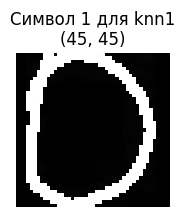

    Предсказан как: '0'


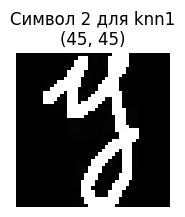

    Предсказан как: 'y'


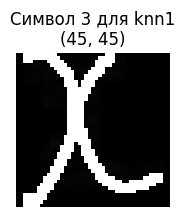

    Предсказан как: 'x'


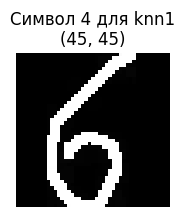

    Предсказан как: '6'


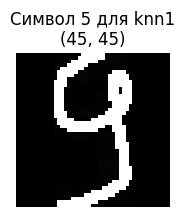

    Предсказан как: '3'


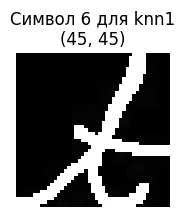

    Предсказан как: 't'


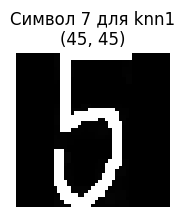

    Предсказан как: '5'


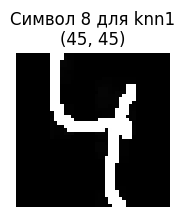

    Предсказан как: '4'


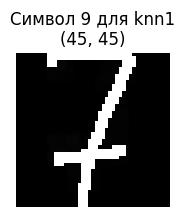

    Предсказан как: '7'


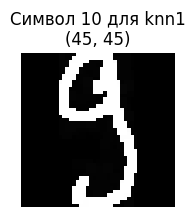

    Предсказан как: '9'
Предсказано: '0yx63t5479'
   Ошибка в позиции 5: ожидалось '9', получено '3'
Accuracy для knn1: 0.90 (9/10 символов)

МОДЕЛЬ: knn3


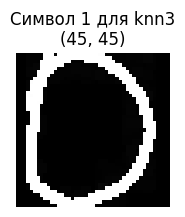

    Предсказан как: '0'


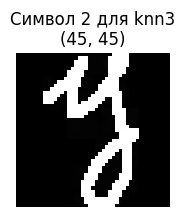

    Предсказан как: 'y'


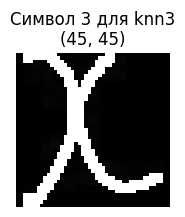

    Предсказан как: 'x'


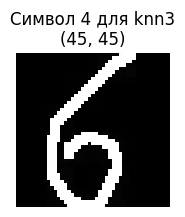

    Предсказан как: '6'


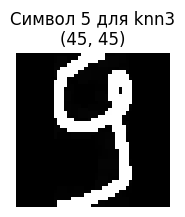

    Предсказан как: '3'


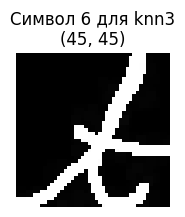

    Предсказан как: 't'


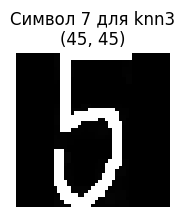

    Предсказан как: '5'


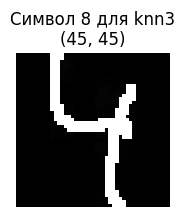

    Предсказан как: '4'


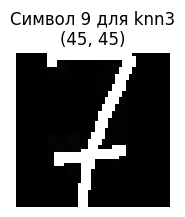

    Предсказан как: '7'


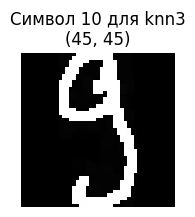

    Предсказан как: '9'
Предсказано: '0yx63t5479'
   Ошибка в позиции 5: ожидалось '9', получено '3'
Accuracy для knn3: 0.90 (9/10 символов)

МОДЕЛЬ: knn5


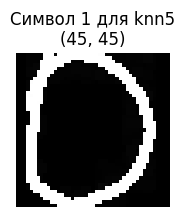

    Предсказан как: '0'


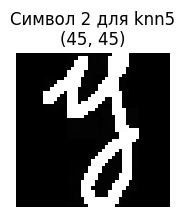

    Предсказан как: 'y'


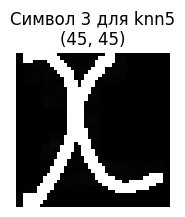

    Предсказан как: 'x'


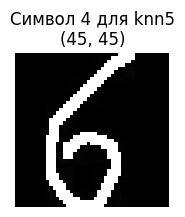

    Предсказан как: '6'


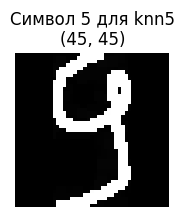

    Предсказан как: '9'


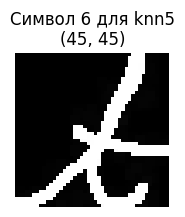

    Предсказан как: 't'


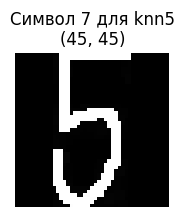

    Предсказан как: '5'


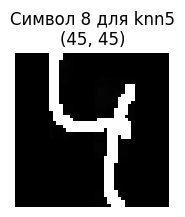

    Предсказан как: '4'


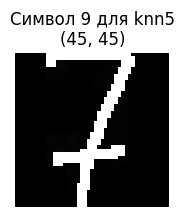

    Предсказан как: '7'


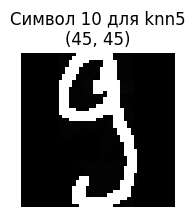

    Предсказан как: '9'
Предсказано: '0yx69t5479'
Accuracy для knn5: 1.00 (10/10 символов)

МОДЕЛЬ: knn7


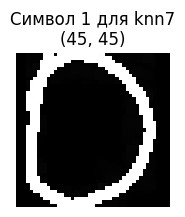

    Предсказан как: '0'


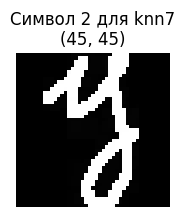

    Предсказан как: 'y'


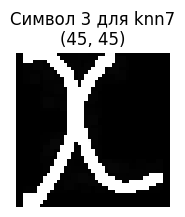

    Предсказан как: 'x'


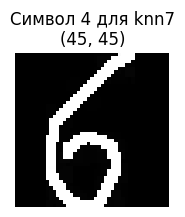

    Предсказан как: '6'


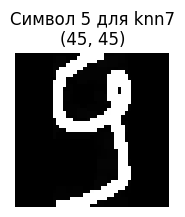

    Предсказан как: '9'


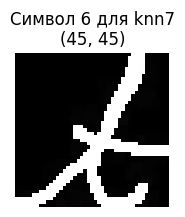

    Предсказан как: 't'


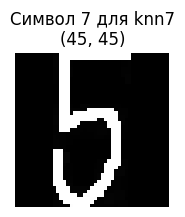

    Предсказан как: '5'


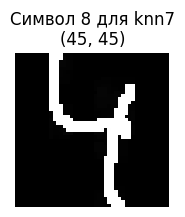

    Предсказан как: '4'


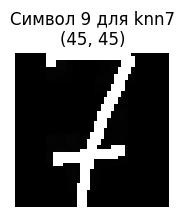

    Предсказан как: '7'


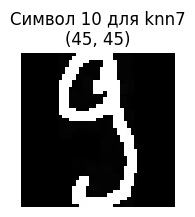

    Предсказан как: '9'
Предсказано: '0yx69t5479'
Accuracy для knn7: 1.00 (10/10 символов)

                            ИТОГО ПО ВСЕМ МОДЕЛЯМ:
knn5  | Accuracy: 100.00% | 10/10 | Предсказание: '0yx69t5479'
knn7  | Accuracy: 100.00% | 10/10 | Предсказание: '0yx69t5479'
knn1  | Accuracy:  90.00% | 9/10 | Предсказание: '0yx63t5479'
knn3  | Accuracy:  90.00% | 9/10 | Предсказание: '0yx63t5479'


In [182]:
seq_data = all_data_img_45[0]
original_text = seq_data['sequence_text']
symbols_data = seq_data['symbols']

print(f"\n Последовательность:")
print(f"Оригинал: '{original_text}'")

models = {
    'knn1': knn1,
    'knn3': knn3, 
    'knn5': knn5,
    'knn7': knn7
}

results = {}

for model_name, model in models.items():
    print(f"\n{'='*50}")
    print(f"МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    predicted_symbols = []
    
    for j, (x, symbol_img) in enumerate(symbols_data):
        plt.figure(figsize=(3, 2))
        plt.imshow(symbol_img, cmap='gray')
        plt.title(f'Символ {j+1} для {model_name}\n{symbol_img.shape}')
        plt.axis('off')
        plt.show()
        
        predicted_char = predict_symbol(model, symbol_img)
        predicted_symbols.append(predicted_char)
        print(f"    Предсказан как: '{predicted_char}'")
    
    predicted_text = ''.join(predicted_symbols)
    print(f"Предсказано: '{predicted_text}'")
    
    correct_chars = sum(1 for orig, pred in zip(original_text, predicted_text) if orig == pred)
    total_chars = len(original_text)
    accuracy = correct_chars / total_chars
    
    if original_text != predicted_text:
        for idx, (orig_char, pred_char) in enumerate(zip(original_text, predicted_text)):
            if orig_char != pred_char:
                print(f"   Ошибка в позиции {idx+1}: ожидалось '{orig_char}', получено '{pred_char}'")
    
    print(f"Accuracy для {model_name}: {accuracy:.2f} ({correct_chars}/{total_chars} символов)")
    
    results[model_name] = {
        'predicted_text': predicted_text,
        'accuracy': accuracy,
        'correct_chars': correct_chars,
        'total_chars': total_chars
    }

print(f"\n{'='*90}")
print("                            ИТОГО ПО ВСЕМ МОДЕЛЯМ:")
print(f"{'='*90}")

sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)

for model_name, result in sorted_results:
    accuracy_percent = result['accuracy'] * 100
    print(f"{model_name:5} | Accuracy: {accuracy_percent:6.2f}% | {result['correct_chars']}/{result['total_chars']} | Предсказание: '{result['predicted_text']}'")